# 06 Robustness Checks

This notebook implements a **Placebo Test (Permutation Test)** using a notebook-local shadow matching workflow to validate that the estimated treatment effect disappears when the treatment assignment is randomized.

Outputs:
- `outputs/figures/fig_09_placebo_ate.png`
- `data/processed/placebo_results.json`


## Section 0: Setup

Conventions (consistent with notebooks 03-05):
- 检测 `project_root`, 并添加到 `sys.path`, 通过 `os.chdir(project_root)` 更换到项目目录
- 加载 `configs/config.yml` 配置
- 使用 config 中的路径 (保证代码的可迁移性) 以及协变量


In [1]:
# ======================================================
# Section 0 (Cell 1/2): Imports + Project Root + Config
# ======================================================
# NOTE:
#   1) Notebook 06 的 Placebo / falsification 采用 notebook 内联的 in-memory shadow matcher。
#   2) 为了和主实验在设计层保持可比性，这里会复用共同的 PS / ATE 工具
#   3) 但不会直接调用 src.causal.match_ps()，也不追求对 Notebook 03 的 matched sample 做逐行复刻。

import os
import sys
import json
from pathlib import Path
from datetime import datetime, timezone, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from IPython.display import Markdown, display

from sklearn.neighbors import NearestNeighbors

# project_root detection (robust to running from ./notebooks)
cwd = Path.cwd().resolve()
project_root = cwd if (cwd / 'configs' / 'config.yml').exists() else cwd.parent
if not (project_root / 'configs' / 'config.yml').exists():
    raise FileNotFoundError('Cannot find configs/config.yml from current working directory')

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)

# Load config
config_candidates = [
    project_root / 'configs' / 'config.yml',
    project_root / 'configs' / 'config.yaml',
]
config_path = next((p for p in config_candidates if p.exists()), None)
if config_path is None:
    raise FileNotFoundError('Missing config.yml/config.yaml under configs/')
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# time anchor (audit-friendly)
tz_utc8 = timezone(timedelta(hours=8))
print('[Time]', datetime.now(tz_utc8).strftime('%Y-%m-%d %H:%M:%S %Z%z'))

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Paths
figures_dir = Path(config['paths']['figures_dir'])
figures_dir.mkdir(parents=True, exist_ok=True)

processed_dir = project_root / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

# Columns
covariates = list(config['data']['covariates'])
treatment_col = str(config['data']['treatment_col'])
outcome_col = str(config['data']['outcome_col'])
random_state = int(config.get('general', {}).get('random_state', 42))

print('[Cols] treatment:', treatment_col, '| outcome:', outcome_col)
print('[Covariates]', len(covariates))
print('[Seed]', random_state)

from src.causal import estimate_ps, compute_ate  # imported after sys.path setup


[Time] 2026-03-16 20:21:48 UTC+08:00+0800
[Cols] treatment: treatment | outcome: conversion
[Covariates] 9
[Seed] 42


In [2]:
# ======================================================
# Section 0 (Cell 2/2): Load Data + Baseline ATE
# ======================================================

features_path = Path(config['paths']['features_data'])
if not features_path.exists():
    raise FileNotFoundError(f'Missing features_data: {features_path}')

df = pd.read_csv(features_path)
print('[Loaded]', features_path, '| shape:', df.shape)

missing_covs = [c for c in covariates if c not in df.columns]
if missing_covs:
    raise ValueError(f'Missing covariates in features df: {missing_covs}')

X = df[covariates].copy()
T = pd.to_numeric(df[treatment_col], errors='coerce').astype(int)
Y = pd.to_numeric(df[outcome_col], errors='coerce').astype(int)

# Row id for mapping matched rows back to covariates (balance check on original match only).
row_id_col = '__row_id'
row_ids = np.arange(len(df), dtype=int)

# Baseline ATE reference (naive, RCT): used as a sanity check only
ate_naive = float(Y[T == 1].mean() - Y[T == 0].mean())
print(f'[Naive ATE] {ate_naive:.6f} ({ate_naive:.3%})')

# Baseline ATE reference for the shadow placebo workflow: run once to get a comparable original_ate + CI
ps, _ = estimate_ps(X, T, random_state=random_state)
# Keep a minimal frame for matching/ATE to avoid full DataFrame copies in loops.
df_with_ps = pd.DataFrame({
    row_id_col: row_ids,
    outcome_col: Y.to_numpy(copy=False),
    treatment_col: T.to_numpy(copy=False),
    'ps': np.asarray(ps, dtype=float),
})


[Loaded] data\processed\hillstrom_features.csv | shape: (64000, 17)
[Naive ATE] 0.004955 (0.495%)


## Section 1: Placebo Test (Permutation Test)

对处理分配 `T` 进行置换，并在 Notebook 06 内以 notebook-local shadow implementation 重新估计 PS、执行 in-memory matching、计算 placebo ATE。
在零假设（无因果效应）下，这条 placebo shadow chain 产出的 ATE 分布应集中在 0 附近。

In [3]:
# ======================================================
# Section 1 (Cell 1/4): Helpers (in-notebook)
# ======================================================

def _match_ps_in_memory(
    df_in: pd.DataFrame,
    *,
    ps_col: str = 'ps',
    treatment_col: str = 'treatment',
    caliper_factor: float = 0.2,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    In-memory 1:1 nearest-neighbor matching on propensity score (no replacement).

    Why in-notebook?
    - `src.causal.match_ps()` 有 "固定将数据落盘写成 CSV" 的副作用, Placebo 是一次性验证, 应该 notebook 内联, 避免过度工程化
    - 这个 helper 是 placebo/falsification 专用的 notebook-local shadow matcher：只对齐主实验的高层 matching 设计 (1:1 NN + caliper + no replacement), 不声称与 Notebook 03 的 matcher 或 matched sample 完全相同
    """
    if ps_col not in df_in.columns:
        raise ValueError(f'Missing ps_col: {ps_col}')
    if treatment_col not in df_in.columns:
        raise ValueError(f'Missing treatment_col: {treatment_col}')

    # Treat df_in as read-only; only matched slices are copied later.
    df_local = df_in

    ps_series = pd.to_numeric(df_local[ps_col], errors='coerce')
    if ps_series.isnull().any():
        raise ValueError('ps contains NaN/non-numeric values')
    ps = ps_series.astype(float).to_numpy()
    if np.isnan(ps).any() or (not np.isfinite(ps).all()):
        raise ValueError('ps contains NaN/inf')

    t_series = pd.to_numeric(df_local[treatment_col], errors='coerce')
    if t_series.isnull().any():
        raise ValueError('treatment contains NaN/non-numeric values')
    t = t_series.astype(int).to_numpy()
    if not set(np.unique(t)).issubset({0, 1}):
        raise ValueError('treatment must be binary (0/1)')

    treated_idx = np.where(t == 1)[0]
    control_idx = np.where(t == 0)[0]
    if treated_idx.size == 0 or control_idx.size == 0:
        raise ValueError('Both treated and control must be non-empty')

    ps_std = float(np.std(ps))

    # Special case (important for placebo):
    #   1. 如果 PS 几乎为常数， kNN 相邻匹配列表可能会相同 (所有对照组用户与处理组用户的 "distance" 都一样)
    #   2. 此时贪婪算法的不放回匹配可能会失败 (重复选择同一个对照组用户)。
    #   3. 在此情况下，采用随机的 1:1 配对是有效的 (从复杂的匹配算法等价退化为随机配对)
    #   4. 空值匹配基线（基于常数 PS 的匹配不包含任何信息）。
    if ps_std < 1e-4:
        rng = np.random.RandomState(random_state)
        n_pairs = int(min(treated_idx.size, control_idx.size))

        # Matched pairs check
        if n_pairs < 10:
            raise ValueError(f'Too few matched pairs: {n_pairs}')
        
        # rng.choice(..., replace=False): No-replacement exact sampling (N = n_pairs)
        chosen_ctrl = rng.choice(control_idx, size=n_pairs, replace=False)
        chosen_treat = rng.choice(treated_idx, size=n_pairs, replace=False)

        # Generate match_id
        pair_ids = np.arange(n_pairs, dtype=int)
        df_treat = df_local.iloc[chosen_treat].copy()
        df_ctrl = df_local.iloc[chosen_ctrl].copy()
        df_treat['match_id'] = pair_ids
        df_ctrl['match_id'] = pair_ids
        return pd.concat([df_treat, df_ctrl], ignore_index=True)

    caliper = float(caliper_factor) * ps_std
    if not np.isfinite(caliper) or caliper < 0:
        raise ValueError('Invalid caliper computed from ps')
    caliper = max(float(caliper), 1e-6)

    # Efficiency note:
    # - 控制组是 Hillstrom 中的较小组 (T:C ~ 2:1)。
    # - 根据已有的 PS 对控制组进行 NN 查询 (反向匹配)，以提升效率
    # (让数量较少的组 (control) 去匹配较大的组 (treatment), 减少时间复杂度)
    treated_ps = ps[treated_idx].reshape(-1, 1)
    control_ps = ps[control_idx].reshape(-1, 1)

    desired_pairs = int(min(treated_idx.size, control_idx.size))

    # Try a smaller k first for speed; fall back to larger k if matching is poor.
    distances = None
    neighbors = None
    matched_ctrl = []
    matched_treat = []

    for k_try in [50, 200]:
        k = int(min(k_try, treated_idx.size))
        k = max(1, k)
        nn = NearestNeighbors(n_neighbors=k, algorithm='kd_tree')
        nn.fit(treated_ps)
        distances, neighbors = nn.kneighbors(control_ps, return_distance=True)

        ctrl_order = np.argsort(distances[:, 0], kind='mergesort')
        used_treated = set()
        matched_ctrl = []
        matched_treat = []

        for ctrl_pos in ctrl_order:
            # If nearest neighbor is farther than caliper, skip this crtl_pos
            if float(distances[ctrl_pos, 0]) > caliper:
                continue

            chosen_treat_pos = None
            for j in range(k):
                if float(distances[ctrl_pos, j]) > caliper:
                    break
                treat_pos = int(neighbors[ctrl_pos, j])
                if treat_pos not in used_treated:
                    chosen_treat_pos = treat_pos
                    break
            # If still None:means no suitable treatment found, skip this ctrl_pos
            if chosen_treat_pos is None:
                continue
            used_treated.add(int(chosen_treat_pos))
            matched_ctrl.append(int(control_idx[int(ctrl_pos)]))
            matched_treat.append(int(treated_idx[int(chosen_treat_pos)]))

        match_rate = float(len(matched_ctrl)) / float(desired_pairs)
        if match_rate >= 0.90 or k == treated_idx.size:
            break

    # (matching already computed in the loop above)
    n_pairs = int(len(matched_ctrl))
    if n_pairs < 10:
        raise ValueError(f'Too few matched pairs: {n_pairs}')

    # Build matched_df in one go (avoid per-row copies).
    pair_ids = np.arange(n_pairs, dtype=int)
    df_treat = df_local.iloc[matched_treat].copy()
    df_ctrl = df_local.iloc[matched_ctrl].copy()
    df_treat['match_id'] = pair_ids
    df_ctrl['match_id'] = pair_ids
    out = pd.concat([df_treat, df_ctrl], ignore_index=True)
    return out


def _ate_point_estimate_from_pairs(
    matched_df: pd.DataFrame,
    *,
    outcome_col: str,
    treatment_col: str,
) -> float:
    """Point estimate ATE using matched pairs (treated - control per match_id)."""
    if 'match_id' not in matched_df.columns:
        raise ValueError('matched_df must contain match_id')

    t = pd.to_numeric(matched_df[treatment_col], errors='coerce')
    y = pd.to_numeric(matched_df[outcome_col], errors='coerce')
    if t.isnull().any() or y.isnull().any():
        raise ValueError('treatment/outcome contains NaN')

    pair_check = (
        matched_df.assign(_t=t.astype(int))
        .groupby('match_id', dropna=False)['_t']
        .agg(size='size', treated_sum='sum')
    )
    if (pair_check['size'] != 2).any() or (pair_check['treated_sum'] != 1).any():
        raise ValueError('Invalid pairing: each match_id must have exactly 2 rows (1 treated, 1 control)')

    pair_outcomes = (
        matched_df.assign(_t=t.astype(int), _y=y.to_numpy(dtype=float, copy=False))
        .pivot_table(index='match_id', columns='_t', values='_y', aggfunc='first')
    )
    diffs = (pair_outcomes[1] - pair_outcomes[0]).to_numpy(dtype=float, copy=False)
    return float(np.mean(diffs))


def _ps_smd(ps_arr: np.ndarray, t_arr: np.ndarray, eps: float = 1e-12) -> float:
    """Cheap balance signal: SMD on propensity score (raw ps)."""
    ps_vec = np.asarray(ps_arr, dtype=float).reshape(-1)
    t_vec = np.asarray(t_arr, dtype=int).reshape(-1)
    if ps_vec.size == 0:
        raise ValueError('ps_arr cannot be empty')
    if ps_vec.size != t_vec.size:
        raise ValueError('ps_arr and t_arr length mismatch')
    if not np.isfinite(ps_vec).all():
        raise ValueError('ps_arr contains NaN/inf')
    if not set(np.unique(t_vec)).issubset({0, 1}):
        raise ValueError('t_arr must be binary (0/1)')

    ps_t = ps_vec[t_vec == 1]
    ps_c = ps_vec[t_vec == 0]
    if ps_t.size == 0 or ps_c.size == 0:
        raise ValueError('Both treated and control must be non-empty')

    denom = float(np.std(ps_vec))
    denom = max(denom, float(eps))
    return float(abs(float(ps_t.mean()) - float(ps_c.mean())) / denom)


def _quick_match_metrics(
    matched_df: pd.DataFrame,
    *,
    desired_pairs: int,
    n_treated_total: int,
    n_control_total: int,
    treatment_col: str,
    ps_col: str = 'ps',
) -> dict:
    """Loop-safe matching metrics: coverage + cheap balance (PS SMD)."""
    if matched_df is None or matched_df.empty:
        raise ValueError('matched_df cannot be empty')
    if 'match_id' not in matched_df.columns:
        raise ValueError('matched_df must contain match_id')

    # Number of matched pairs
    n_pairs = int(matched_df['match_id'].nunique())
    # Theoretical maximum match rate = n_pairs / min{n_treated, n_control}
    match_rate_max = float(n_pairs) / float(max(1, desired_pairs))
    # Used ratio of control samples
    match_rate_control = float(n_pairs) / float(max(1, n_control_total))
    # Used ratio of treated samples
    treated_utilization = float(n_pairs) / float(max(1, n_treated_total))

    t_vec = pd.to_numeric(matched_df[treatment_col], errors='coerce')
    if t_vec.isnull().any():
        raise ValueError('treatment contains NaN/non-numeric values')
    t_arr = t_vec.astype(int).to_numpy()

    ps_vec = pd.to_numeric(matched_df[ps_col], errors='coerce')
    if ps_vec.isnull().any():
        raise ValueError('ps contains NaN/non-numeric values')
    ps_arr = ps_vec.astype(float).to_numpy()

    # SMD of PS after matching
    ps_smd_after = _ps_smd(ps_arr, t_arr)

    treated_n = int((t_arr == 1).sum())
    control_n = int((t_arr == 0).sum())

    # Check integrity of matched_df:
    integrity_counts_ok = (treated_n == n_pairs) and (control_n == n_pairs) and (len(matched_df) == 2 * n_pairs)

    return {
        'n_pairs': int(n_pairs),
        'match_rate_max': float(match_rate_max), 
        'match_rate_control': float(match_rate_control),
        'treated_utilization': float(treated_utilization),
        'ps_smd_after': float(ps_smd_after),
        'integrity_counts_ok': bool(integrity_counts_ok),
    }


**Helper: _match_ps_in_memory()**:
1) **ALgorithm**: 贪婪不放回匹配算法,对于每个 control ，选一个不冲突的且使得总距离小的 treatment 进行匹配。如果后续需要使用全局最优算法 (性能开销大), 可以采用 Assignment Problem (Hungarian Algorithm)
    - 建立代价矩阵 $C_{ij} = D_{ij}$, 把超出 caliper 的边设为无穷大
    - 求解 $min(C_{ij})$ 的最优解 (做最小代价匹配--Hungarian / min cost flow)
2) **Numerical processing**: 
    - 代码使用的是 $distance = |ps_c - ps_t|$ 和 $caliper = 0.2 * std(ps)$
    - 文献中常用 $distance = |logit(ps_c) - logit(ps_t)|$ 和 $caliper = 0.2 * sd(logit(ps))$(Logistic 变换) 
    - 本项目为了让 placebo falsification 与 Phase 2 在设计层可比, 默认使用前者。这里强调的是 design alignment, 而不是与 Notebook 03 的 matcher / 配对结果逐步完全一致。后者作为可选拓展用语进一步稳健性对照

**Logistic 变换**: $\text{logit}(p) = \ln\left(\frac{p}{1-p}\right)$

**Helper: _ate_point_estimate_from_pairs()**:
1) **ATE Computation**:
  - 公式：$$\widehat{ATE}_{pair}=\frac{1}{n}\sum_{k=1}^{n}\left(Y_{k,1}-Y_{k,0}\right)$$
  - 方法: 在 PSM 后用 "配对差分均值" 估计处理效应：对每个匹配对计算 Y_treated - Y_control，再对所有匹配对取平均。
  - 估计对象的变化: 由于 caliper/no-replacement 会丢弃不可匹配样本，这个估计量更接近 overlap/matched sample 上的平均处理效应 (ATT on matched sample)
  - 优势: Matching 的价值在于降低可观测混杂后, 配对差值更稳定 (方差更小);
  - 预见性防御: 由于配对过程中会丢弃样本, 如果样本量损失过大会导致不稳定。因为代码中对匹配率进行了监控

---

In [4]:
# ======================================================
# Section 1 (Cell 2/4): Run Placebo Permutations
# ======================================================

# ----------------------------------------------------
# 1) Compute Basic Stats
# ----------------------------------------------------
# Baseline original ATE for the notebook-local shadow matcher, computed once with bootstrap CI
n_treated_total = int((T.to_numpy(dtype=int, copy=False) == 1).sum())
n_control_total = int((T.to_numpy(dtype=int, copy=False) == 0).sum())
desired_pairs = int(min(n_treated_total, n_control_total))

MATCH_RATE_THRESHOLD = 0.90
print('=' * 70)
print('Shadow Matching Monitor (Original + Placebo)')
print('=' * 70)
print(f'Total samples:   Control={n_control_total:,} | Treated={n_treated_total:,} | MaxPairs={desired_pairs:,}\n')


# ----------------------------------------------------
# 2) Matching
# ----------------------------------------------------
matched_original = _match_ps_in_memory(
    df_with_ps,
    ps_col='ps',
    treatment_col=treatment_col,
    caliper_factor=float(config.get('psm', {}).get('caliper_factor', 0.2)),
    random_state=random_state,
)
orig_metrics = _quick_match_metrics(
    matched_original,
    desired_pairs=desired_pairs,
    n_treated_total=n_treated_total,
    n_control_total=n_control_total,
    treatment_col=treatment_col,
    ps_col='ps',
)

ps_smd_before = _ps_smd(
    df_with_ps['ps'].to_numpy(dtype=float, copy=False),
    df_with_ps[treatment_col].to_numpy(dtype=int, copy=False),
)

print(f'[Match][Original] n_pairs={orig_metrics["n_pairs"]:,} | match_rate_max={orig_metrics["match_rate_max"]:.2%} | match_rate_control={orig_metrics["match_rate_control"]:.2%} | treated_utilization={orig_metrics["treated_utilization"]:.2%}')
print(f'[Balance][PS] smd_before={ps_smd_before:.4f} | smd_after={orig_metrics["ps_smd_after"]:.4f} | integrity_counts_ok={orig_metrics["integrity_counts_ok"]}\n')
if orig_metrics["match_rate_max"] < MATCH_RATE_THRESHOLD:
    print(f'WARN: Original match_rate_max {orig_metrics["match_rate_max"]:.2%} < {MATCH_RATE_THRESHOLD:.0%}. Estimand is heavily trimmed to overlap subset.\n')


# ----------------------------------------------------
# 3) Compute Original ATE
# ----------------------------------------------------
ate_result = compute_ate(
    matched_original,
    outcome_col=outcome_col,
    treatment_col=treatment_col,
    n_bootstrap=1000,
    random_state=random_state,
    ate_naive_conv=ate_naive,
)
original_ate = float(ate_result['ate'])
print(f'[Original ATE | Shadow matcher] {original_ate:.6f} ({original_ate:.3%}) | 95% CI [{ate_result["ci_lower"]:.6f}, {ate_result["ci_upper"]:.6f}]\n')


# ----------------------------------------------------
# 4) Covariate Balance Check (Original Match Only)
# ----------------------------------------------------
# Do not run in placebo loop
from src.causal import check_balance
df_after_full = df.iloc[matched_original[row_id_col].to_numpy(dtype=int, copy=False)].copy()
balance_report = check_balance(df_before=df, df_after=df_after_full, covariates=covariates, treatment_col=treatment_col)
max_smd_after = float(balance_report['smd_after'].max())
pct_balanced = float((balance_report['smd_after'] < 0.1).mean())
worst = balance_report.sort_values('smd_after', ascending=False).head(3)[['covariate', 'smd_after']]
print(f'[Balance][Covariates] max_smd_after={max_smd_after:.4f} | pct_smd_after<0.10={pct_balanced:.2%}')
print('[Balance][Worst 3]')
print(worst.to_string(index=False))
print('\n')


# ----------------------------------------------------
# 5) Placebo Permutations
# ----------------------------------------------------
n_permutations = 200
if n_permutations < 100:
    raise ValueError('n_permutations must be >= 100')

# Initialization
rng = np.random.RandomState(random_state)
placebo_ates: list[float] = []
placebo_match_rate_max: list[float] = []
placebo_ps_smd_after: list[float] = []
placebo_ps_std: list[float] = []
n_low_match_rate = 0

caliper_factor_default = float(config.get('psm', {}).get('caliper_factor', 0.2))

for i in range(int(n_permutations)):
    # Shuffle treatment lable 
    # But keep the treated/control ratio unchanged (a permutation)
    t_shuffled = rng.permutation(T.to_numpy(dtype=int, copy=False))

    try:
        ps_i, _ = estimate_ps(X, t_shuffled, random_state=int(random_state + i))
        placebo_ps_std.append(float(np.std(np.asarray(ps_i, dtype=float))))
        df_temp = pd.DataFrame({
            row_id_col: row_ids,
            outcome_col: Y.to_numpy(copy=False),
            treatment_col: t_shuffled,
            'ps': np.asarray(ps_i, dtype=float),
        })

        matched_i = _match_ps_in_memory(
            df_temp,
            ps_col='ps',
            treatment_col=treatment_col,
            caliper_factor=caliper_factor_default,
            random_state=int(random_state + i),
        )
        m_i = _quick_match_metrics(
            matched_i,
            desired_pairs=desired_pairs,
            n_treated_total=n_treated_total,
            n_control_total=n_control_total,
            treatment_col=treatment_col,
            ps_col='ps',
        )
        placebo_match_rate_max.append(float(m_i['match_rate_max']))
        placebo_ps_smd_after.append(float(m_i['ps_smd_after']))
        if float(m_i['match_rate_max']) < MATCH_RATE_THRESHOLD:
            n_low_match_rate += 1
        ate_i = _ate_point_estimate_from_pairs(
            matched_i,
            outcome_col=outcome_col,
            treatment_col=treatment_col,
        )
    except Exception as e:
        ps_std_i = float(np.std(np.asarray(ps_i, dtype=float))) if 'ps_i' in locals() else float('nan')
        raise RuntimeError(f'Placebo permutation {i} failed: {e} | ps_std={ps_std_i:.3e}') from e

    placebo_ates.append(float(ate_i))

    if (i + 1) % 20 == 0:
        print(f'  - permutations: {i+1}/{n_permutations} done | match_rate_max={m_i["match_rate_max"]:.2%} | ps_smd_after={m_i["ps_smd_after"]:.4f}')

placebo_arr = np.asarray(placebo_ates, dtype=float)
placebo_mean = float(placebo_arr.mean())
placebo_std = float(placebo_arr.std(ddof=1))
print('\n')

# ----------------------------------------------------
# 6) Match Monitoring Summary (Placebo Loop)
# ----------------------------------------------------
mr = np.asarray(placebo_match_rate_max, dtype=float)
pss = np.asarray(placebo_ps_smd_after, dtype=float)
psstd = np.asarray(placebo_ps_std, dtype=float)
low_frac = float(n_low_match_rate) / float(max(1, n_permutations))
const_frac = float((psstd < 1e-4).mean()) if psstd.size > 0 else float('nan')

print(f'[Match][Placebo] match_rate_max min/p50/p95 = {np.min(mr):.2%} / {np.percentile(mr, 50):.2%} / {np.percentile(mr, 95):.2%}')
print(f'[Balance][Placebo][PS] ps_smd_after min/p50/p95 = {np.min(pss):.4f} / {np.percentile(pss, 50):.4f} / {np.percentile(pss, 95):.4f}')
print(f'[Match][Placebo] frac(match_rate_max<{MATCH_RATE_THRESHOLD:.0%}) = {low_frac:.2%} | frac(ps_std<1e-4) = {const_frac:.2%}\n')


# ----------------------------------------------------
# 7) Permutation p-value (add-one correction)
# ----------------------------------------------------
n = int(n_permutations)
if float(original_ate) >= 0.0:
    tail = int(np.sum(placebo_arr >= float(original_ate)))
else:
    tail = int(np.sum(placebo_arr <= float(original_ate)))
p_value = float((tail + 1) / (n + 1))

# Optional diagnostic: two-sided p-value
tail_two = int(np.sum(np.abs(placebo_arr) >= abs(float(original_ate))))
p_value_two_sided = float((tail_two + 1) / (n + 1))

# PRD-style validation checks (soft): print warnings but do not block artifact generation
assert len(placebo_ates) == n_permutations, 'Placebo permutations count mismatch'
perm_se = float(placebo_std / np.sqrt(n_permutations))
if abs(placebo_mean) > 3.0 * perm_se:
    print(f'WARN: placebo_mean={placebo_mean:.6f} is not close to 0 vs permutation SE={perm_se:.6f}')
if p_value >= 0.05:
    print(f'WARN: placebo one-sided p_value={p_value:.4f} (original ATE not extreme vs null)')

print(f'[Placebo] mean={placebo_mean:.6f}, std={placebo_std:.6f}, p_one_sided={p_value:.4f}, p_two_sided={p_value_two_sided:.4f}')


Shadow Matching Monitor (Original + Placebo)
Total samples:   Control=21,306 | Treated=42,694 | MaxPairs=21,306

[Match][Original] n_pairs=21,305 | match_rate_max=100.00% | match_rate_control=100.00% | treated_utilization=49.90%
[Balance][PS] smd_before=0.0181 | smd_after=0.0000 | integrity_counts_ok=True

[Original ATE | Shadow matcher] 0.005210 (0.521%) | 95% CI [0.003426, 0.007042]

[Balance][Covariates] max_smd_after=0.0127 | pct_smd_after<0.10=100.00%
[Balance][Worst 3]
    covariate  smd_after
       newbie   0.012674
    zip_Urban   0.009855
channel_Phone   0.006336


  - permutations: 20/200 done | match_rate_max=100.00% | ps_smd_after=0.0000
  - permutations: 40/200 done | match_rate_max=100.00% | ps_smd_after=0.0000
  - permutations: 60/200 done | match_rate_max=99.99% | ps_smd_after=0.0000
  - permutations: 80/200 done | match_rate_max=100.00% | ps_smd_after=0.0000
  - permutations: 100/200 done | match_rate_max=100.00% | ps_smd_after=0.0000
  - permutations: 120/200 done | 

**Match Rate Monitoring**

1) **Coverage**：用三种 match-rate 口径描述 "样本损失数" 
    - match_rate_max: 对 "理论最大可匹配对数" 的比例 (最公平)
    - match_rate_control: 控制组覆盖率 (最直观)
    - treated_utilization: 处理组被用掉的比例 (解释 2:1 结构下为什么 treated 会剩很多)
2) **Integrity**: 每次 permutation 都验证 (匹配对结构是否可靠)
    - _ate_point_estimate_from_pairs() 的 pair-level 检查 (每个 match_id size=2、treated_sum=1)
    - 代码强制每次都检查, 否则直接 fail-fast
3) **Quality**：一轻一重 (匹配后是否更可比)
    - 轻 (loop-safe): ps_smd_after 每次 permutation 都能快速发现异常  
    - 重 (只做一次): original match 的 covariate SMD (check_balance 输出) 证明 "匹配后协变量更平衡"
4) **Interpretability**：阈值警告 + 明确解释 estimand 
    - match_rate_max < 0.90 不强制 fail，但会警告: 说明结果更偏 overlap 子样本 (estimand 更 trimmed)，避免把结果外推到全体
5) **Auditability** (后续 Cell 4 完成)：关键监控指标落盘到 placebo_results.json
    - robustness 是可复现 artifact  (指标可复现, 追溯)

---

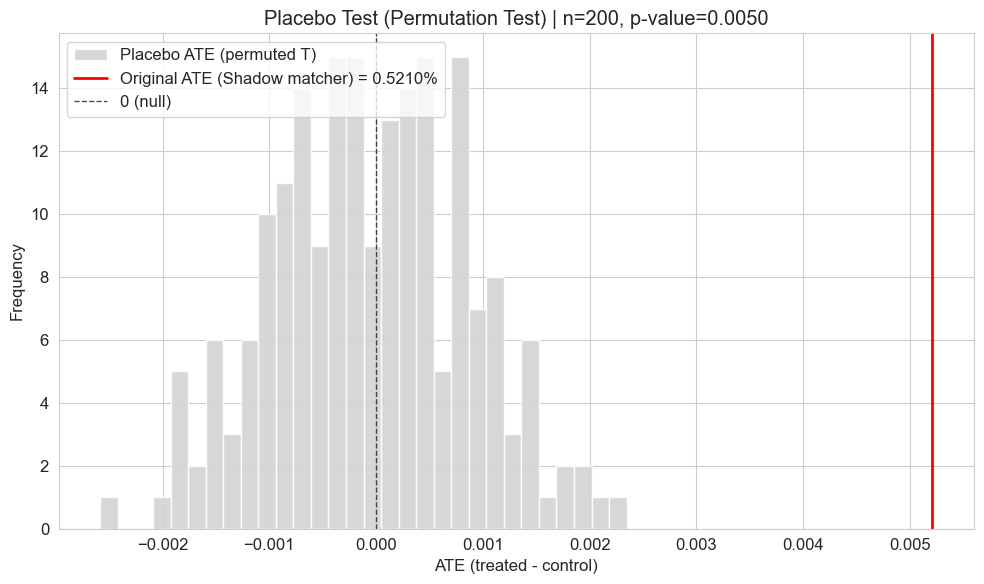

.png saved: outputs\figures\fig_09_placebo_ate.png


<Figure size 1000x600 with 0 Axes>

In [5]:
# ======================================================
# Section 1 (Cell 3/4): Plot + Save Figure
# ======================================================

out_fig = figures_dir / 'fig_09_placebo_ate.png'

plt.figure(figsize=(10, 6))
plt.hist(placebo_arr, bins=30, color='lightgray', edgecolor='white', alpha=0.9, label='Placebo ATE (permuted T)')
plt.axvline(original_ate, color='red', linestyle='-', linewidth=2, label=f'Original ATE (Shadow matcher) = {original_ate:.4%}')
plt.axvline(0.0, color='black', linestyle='--', linewidth=1, alpha=0.7, label='0 (null)')

plt.title(f'Placebo Test (Permutation Test) | n={n_permutations}, p-value={p_value:.4f}')
plt.xlabel('ATE (treated - control)')
plt.ylabel('Frequency')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

out = figures_dir / 'fig_09_placebo_ate.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'.png saved: {out}')


In [6]:
# ======================================================
# Section 1 (Cell 4/4): Persist Results JSON
# ======================================================

out_json = Path('data') / 'processed' / 'placebo_results.json'

payload = {
    'meta': {
        'n_permutations': int(n_permutations),
        'random_state': int(random_state),
        'caliper_factor': float(caliper_factor_default),
        'match_rate_threshold': float(MATCH_RATE_THRESHOLD),
        'original_ate_psm': float(original_ate),
        'original_ate_naive': float(ate_naive),
        'original_n_pairs': int(orig_metrics['n_pairs']),
        'original_match_rate_max': float(orig_metrics['match_rate_max']),
        'original_match_rate_control': float(orig_metrics['match_rate_control']),
        'original_treated_utilization': float(orig_metrics['treated_utilization']),
        'original_ps_smd_before': float(ps_smd_before),
        'original_ps_smd_after': float(orig_metrics['ps_smd_after']),
        'original_integrity_counts_ok': bool(orig_metrics['integrity_counts_ok']),
        'original_balance_max_smd_after': float(max_smd_after),
        'original_balance_pct_smd_after_lt_0_10': float(pct_balanced),
        'placebo_mean': float(placebo_mean),
        'placebo_std': float(placebo_std),
        'p_value_one_sided': float(p_value),
        'p_value_two_sided': float(p_value_two_sided),
        'placebo_match_rate_max_p05': float(np.percentile(mr, 5)),
        'placebo_match_rate_max_p50': float(np.percentile(mr, 50)),
        'placebo_match_rate_max_p95': float(np.percentile(mr, 95)),
        'placebo_ps_smd_after_p05': float(np.percentile(pss, 5)),
        'placebo_ps_smd_after_p50': float(np.percentile(pss, 50)),
        'placebo_ps_smd_after_p95': float(np.percentile(pss, 95)),
        'placebo_low_match_rate_frac': float(low_frac),
        'placebo_ps_std_lt_1e_4_frac': float(const_frac),
    },
    'placebo_ates': [float(x) for x in placebo_arr.tolist()],
}

with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(payload, f, ensure_ascii=True, indent=2)

print(f'.json saved: {out_json}')

md = f"""
### Section 1 Summary

**Workflow**:
1) **Definition of Helpers**: 定义了一个 notebook-local 的 shadow matcher，以及与之配套的 ATE 与匹配质量监控函数；该实现用于 placebo falsification，而不是逐步回放 Notebook 03
2) **Placebo Test & Monitor**: 完成 Placebo 测试 (随机交换 T/C 后计算 ATE), 并同步记录并打印各项数据以监控匹配质量
3) **Visualization**: 输出 placebo ATE 分布图，并进行持久化保存
4) **Data Storage**: 对完成 Placebo Test 的数据进行持久化保存

**Core Figures**:
1) **Matching Quality**: shadow matcher 下的各项质量指标
    - 协变量 SMD 小于 0.1 的概率: {pct_balanced:.2%}
2) **Placebo Distribution**: 完成 Placebo 后 ATE 分布参数为
    - 匹配率小于阈值 {MATCH_RATE_THRESHOLD:.0%} 的概率: {low_frac:.2%}
    - 均值: {placebo_mean:.6f}
    - 标准差: {placebo_std:.6f}
    - p-value (one-sided): {p_value:.4f}
    - p-value (two-sided): {p_value_two_sided:.4f}
    - Placebo Test ATE 分布图

**Insights**:
1) shadow matcher 下的各项质量指标均小于阈值 0.10, 表明 placebo notebook 内的匹配过程保持稳定。出现 SMD = 0.0000 的情况, 是因为 SMD 过小、显示时被截断, 并不说明 SMD 真为零
2) 通过各项分布指标以及分布图, 可以看出 placebo ATE 分布集中在 0 附近, 这说明:
    - 这条与 Phase 2 设计对齐的 notebook-local shadow "PS -> matching -> ATE" 链路没有系统性偏移
    - 实现了关键断言: 第一类错误 (假阳性) 没有被这条 placebo shadow chain 放大

---
"""
display(Markdown(md))


.json saved: data\processed\placebo_results.json



### Section 1 Summary

**Workflow**:
1) **Definition of Helpers**: 定义了一个 notebook-local 的 shadow matcher，以及与之配套的 ATE 与匹配质量监控函数；该实现用于 placebo falsification，而不是逐步回放 Notebook 03
2) **Placebo Test & Monitor**: 完成 Placebo 测试 (随机交换 T/C 后计算 ATE), 并同步记录并打印各项数据以监控匹配质量
3) **Visualization**: 输出 placebo ATE 分布图，并进行持久化保存
4) **Data Storage**: 对完成 Placebo Test 的数据进行持久化保存

**Core Figures**:
1) **Matching Quality**: shadow matcher 下的各项质量指标
    - 协变量 SMD 小于 0.1 的概率: 100.00%
2) **Placebo Distribution**: 完成 Placebo 后 ATE 分布参数为
    - 匹配率小于阈值 90% 的概率: 0.00%
    - 均值: -0.000064
    - 标准差: 0.000914
    - p-value (one-sided): 0.0050
    - p-value (two-sided): 0.0050
    - Placebo Test ATE 分布图

**Insights**:
1) shadow matcher 下的各项质量指标均小于阈值 0.10, 表明 placebo notebook 内的匹配过程保持稳定。出现 SMD = 0.0000 的情况, 是因为 SMD 过小、显示时被截断, 并不说明 SMD 真为零
2) 通过各项分布指标以及分布图, 可以看出 placebo ATE 分布集中在 0 附近, 这说明:
    - 这条与 Phase 2 设计对齐的 notebook-local shadow "PS -> matching -> ATE" 链路没有系统性偏移
    - 实现了关键断言: 第一类错误 (假阳性) 没有被这条 placebo shadow chain 放大

---


## Section 2: Permutation Test (Placebo)

### Goal (Falsification)
Placebo test 是一个 **falsification test**：验证一条与 Phase 2 设计对齐、但由 Notebook 06 在本地内存中重建的 `PS -> matching -> ATE` shadow chain，在 **没有因果效应** 的世界里不会"凭空造出"显著效果。

### Null & Test Statistic
- Null hypothesis: $H_0: Y(1) - Y(0) = 0$
- Test statistic (here, matched-pair ATE on the notebook-local shadow matcher): $\widehat{ATE}_{pair}=\frac{1}{n}\sum_{k=1}^{n}(Y_{k,1}-Y_{k,0})$

在 $H_0$ 下，处理分配 $T$ 与结果 $Y$ 独立（$T \perp Y$），因此打乱 $T$ 标签后，这条 placebo shadow chain 估计得到的 matched-pair ATE 期望应接近 0。

### Procedure (What We Permute)
- 固定 `X`、`Y` 不变，只对 `T` 做 permutation（置换），从而保持 treated/control 的样本量比例不变。
- 对每次置换后的 $T$：重新估计 PS，并使用 Notebook 06 的 notebook-local in-memory shadow matcher（1:1 NN + caliper + no replacement）计算一条 placebo ATE；这里不复用 Notebook 03 的 matcher 或 matched sample。
- 重复 $n_{permutations}$ 次，得到经验分布 $\{\widehat{ATE}_{placebo}^{(b)}\}_{b=1}^B$。

### p-value (Add-One Correction)
本 notebook 同时输出 one-sided 和 two-sided：
- One-sided (PRD, assume effect direction is >= 0):
  $$p_{one} = P(\widehat{ATE}_{placebo} \ge \widehat{ATE}_{orig} \mid H_0) \approx \frac{\#\{\widehat{ATE}_{placebo} \ge \widehat{ATE}_{orig}\} + 1}{B + 1}$$
- Two-sided (no direction assumption):
  $$p_{two} = P(|\widehat{ATE}_{placebo}| \ge |\widehat{ATE}_{orig}| \mid H_0) \approx \frac{\#\{|\widehat{ATE}_{placebo}| \ge |\widehat{ATE}_{orig}|\} + 1}{B + 1}$$

Add-one correction 的意义：避免有限置换次数下出现 `p=0`（更审计友好）。

### Interpretation (How To Read The Plot)
- 如果 placebo ATE 的分布集中在 0 附近，说明：$\mathbb{E}[\widehat{ATE}_{placebo}] \approx 0$
  - 直觉：这条 placebo shadow chain 没有系统性偏移（不会在随机标签下也持续产出非零效果）。
- 如果原始 $\widehat{ATE}_{orig}$（红线）落在 placebo 分布的尾部（p-value 小），说明原始效果很难由"随机波动"解释。

### What This Test Does NOT Prove
- Placebo 通过不代表"已完全消除混杂"，它只能排除一类常见伪发现：比如 post-treatment leakage、计算链路偏置、匹配对结构错误等；同时它支持的是一条与 Phase 2 设计对齐的 shadow placebo workflow，而不是对 Notebook 03 的逐行 replay。
- 因此它应与 balance check（SMD）、coverage（match rate）、以及业务合理性一起作为证据链。

### Audit Artifact
关键指标与 placebo ATE 序列会落盘到 `data/processed/placebo_results.json`，用于复现与审计。